# Assignment 2 — Georgian Spellcheck
## Notebook: `data_and_training.ipynb`

**Task:** Character-level sequence-to-sequence correction of misspelled Georgian words  
**Architecture:** Bidirectional GRU Encoder → Bahdanau Attention → GRU Decoder  
**Dataset:** 1.46 M (input, target) pairs from the Georgian Wikipedia dump  

### Why encoder-decoder?
Output length can differ from input length (an omission makes the input *shorter*
than the correct word; an insertion makes it *longer*). A single sequence model
forces a fixed position-to-position alignment. An encoder-decoder separates
**reading** the corrupted word from **writing** the corrected one, so the decoder
can emit any length regardless of input. Bahdanau attention gives the decoder a
soft pointer into the encoder outputs at every generation step — critical for the
copy behaviour needed when a word is already correct.

In [15]:
# Kaggle already has torch/sklearn; kagglehub may need installing
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=True)
print("imports ready")

imports ready


In [16]:
import json, math, os, random, time, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## 1 — Data Collection

The dataset was produced offline by:
1. Streaming the Georgian Wikipedia XML dump (`kawiki-20251101`, ~82 MB CSV output)
2. Stripping all MediaWiki markup; keeping Georgian-only tokens, length 3–20, freq ≥ 3
3. Generating synthetic errors per word using five error types weighted by real typing patterns
4. Adding 25 % identity pairs so the model learns to pass correct words through unchanged

The pre-built CSV and character vocabulary are loaded here from Kaggle Datasets.

In [17]:
dataset_dir = Path(kagglehub.dataset_download("giorgicheishvili/georgian-spellchecker-dataset"))
print(f"Downloaded to : {dataset_dir}")
print("Files         :", [f.name for f in sorted(dataset_dir.iterdir())])

Downloaded to : /kaggle/input/datasets/giorgicheishvili/georgian-spellchecker-dataset
Files         : ['char_vocab.json', 'georgian_spellcheck_dataset.csv', 'georgian_vocabulary.txt']


In [18]:
csv_path   = dataset_dir / "georgian_spellcheck_dataset.csv"
vocab_path = dataset_dir / "char_vocab.json"

df_full    = pd.read_csv(csv_path, encoding="utf-8")
with open(vocab_path, encoding="utf-8") as f:
    char_vocab = json.load(f)

n_id  = (df_full["input_text"] == df_full["target_text"]).sum()
n_err = len(df_full) - n_id

print(f"Total pairs    : {len(df_full):,}")
print(f"Unique targets : {df_full['target_text'].nunique():,}")
print(f"Identity pairs : {n_id:,}  ({n_id/len(df_full)*100:.1f}%)")
print(f"Error pairs    : {n_err:,}  ({n_err/len(df_full)*100:.1f}%)")
print(f"Vocab size     : {char_vocab['vocab_size']} characters")
print(f"Special tokens : PAD={char_vocab['PAD_IDX']}  SOS={char_vocab['SOS_IDX']}"
      f"  EOS={char_vocab['EOS_IDX']}  UNK={char_vocab['UNK_IDX']}")

Total pairs    : 1,461,204
Unique targets : 365,291
Identity pairs : 365,301  (25.0%)
Error pairs    : 1,095,903  (75.0%)
Vocab size     : 43 characters
Special tokens : PAD=0  SOS=1  EOS=2  UNK=3


## 2 — Data Generation: Methodology & Examples

Five error types were applied with the following weights:

| Error type | Weight | Description | Example |
|---|---|---|---|
| `keyboard_swap` | 35 % | Replace with adjacent key on Georgian QWERTY | `გამარ**ჯ**ობა` → `გამარ**ჰ**ობა` |
| `transposition` | 25 % | Swap two adjacent characters | `**თბ**ილისი` → `**ბთ**ილისი` |
| `omission` | 20 % | Delete one character | `პრო**გრ**ამა` → `პრო**გ**ამა` |
| `phonetic_swap` | 12 % | Confuse ejective/aspirate consonant pairs | `**კ**არგი` → `**ქ**არგი` |
| `insertion` | 8 % | Insert a spurious nearby character | `სახელი` → `სახელ**ი**ს` |

75 % of pairs use exactly 1 edit; 25 % use 2 edits.  
Identity pairs (correct→correct) teach the model **not to change** already-correct inputs.

In [19]:
err_sample = df_full[df_full["input_text"] != df_full["target_text"]].sample(20, random_state=7)
id_sample  = df_full[df_full["input_text"] == df_full["target_text"]].sample(5,  random_state=7)

print("── Error pairs ─────────────────────────────────────────")
print(f"  {'INPUT':<24} → TARGET")
print("  " + "─" * 42)
for _, r in err_sample.iterrows():
    print(f"  {r['input_text']:<24}   {r['target_text']}")

print()
print("── Identity pairs (already correct) ───────────────────")
for _, r in id_sample.iterrows():
    print(f"  {r['input_text']}")

── Error pairs ─────────────────────────────────────────
  INPUT                    → TARGET
  ──────────────────────────────────────────
  კარეჯლიტებს                კარმელიტებს
  მინაჰასიშ                  მინაჰასის
  კითხლუობდნენ               კითხულობდნენ
  სანსკრიტსწ                 სანსკრიტსა
  სივოას                     სიოვას
  დაპროგამება                დაპროგრამება
  თზვრიზი                    თავრიზი
  მრდიაკომპანიების           მედიაკომპანიების
  ყამოაკსთა                  გამოაკეთა
  ააგე                       ავაგე
  პრივილეგიებჯსგწნ           პრივილეგიებისგან
  ტელერეგუი                  ტელერები
  ტაიაფ                      ტაიფა
  კოორდინაციჯსა              კოორდინაციისა
  ვიიტს                      ვიტის
  მოძრაოსბ                   მოძრაობს
  სამფარვეოლ                 სამფარველო
  ფახი                       ცახი
  სწასმ                      სწამს
  წყივლზე                    წყვილზე

── Identity pairs (already correct) ───────────────────
  განაწილებათა
  კომლისგან


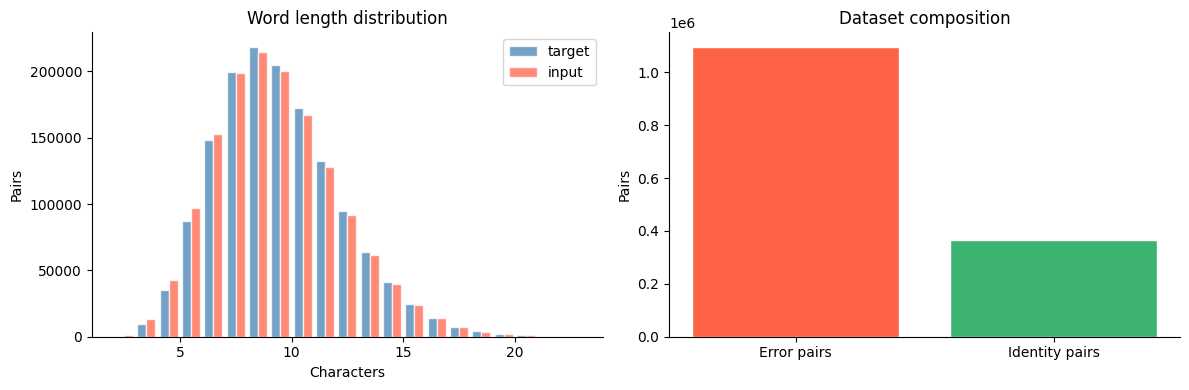

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tlen = df_full["target_text"].str.len()
ilen = df_full["input_text"].str.len()

axes[0].hist([tlen, ilen], bins=range(2, 24), label=["target", "input"],
             color=["steelblue", "tomato"], alpha=0.75, edgecolor="white")
axes[0].set_title("Word length distribution"); axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Pairs"); axes[0].legend()

axes[1].bar(["Error pairs", "Identity pairs"], [n_err, n_id],
            color=["tomato", "mediumseagreen"], edgecolor="white")
axes[1].set_title("Dataset composition"); axes[1].set_ylabel("Pairs")

for ax in axes:
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

## 3 — Train / Validation Split

In [21]:
train_df, val_df = train_test_split(df_full, test_size=0.05, random_state=SEED, shuffle=True)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
print(f"Train : {len(train_df):,} pairs")
print(f"Val   : {len(val_df):,} pairs")

Train : 1,388,143 pairs
Val   : 73,061 pairs


## 4 — Data Pipeline

### Character vocabulary
| Token | Index | Role |
|---|---|---|
| `<PAD>` | 0 | Pad sequences to uniform batch length |
| `<SOS>` | 1 | Decoder start-of-sequence token |
| `<EOS>` | 2 | Decoder end-of-sequence token |
| `<UNK>` | 3 | Out-of-vocabulary fallback |

### Padding
- `MAX_INPUT_LEN = 25` — covers max observed input length of 22, with 3-char buffer
- `MAX_TARGET_LEN = 25` — covers max observed target length of 20 + SOS + EOS + buffer
- Sequences longer than these limits are truncated (affects < 0.01 % of data)

In [22]:
# ── Constants derived from char_vocab.json ────────────────────────────────
PAD_IDX    = char_vocab["PAD_IDX"]    # 0
SOS_IDX    = char_vocab["SOS_IDX"]    # 1
EOS_IDX    = char_vocab["EOS_IDX"]    # 2
UNK_IDX    = char_vocab["UNK_IDX"]    # 3
VOCAB_SIZE = char_vocab["vocab_size"] # 43

char2idx = char_vocab["char2idx"]
idx2char = {int(k): v for k, v in char_vocab["idx2char"].items()}

MAX_INPUT_LEN  = 25
MAX_TARGET_LEN = 25


def word_to_ids(word: str, max_len: int) -> list[int]:
    """Encode a word to a right-padded list of indices (no special tokens)."""
    ids = [char2idx.get(c, UNK_IDX) for c in word[:max_len]]
    ids += [PAD_IDX] * (max_len - len(ids))
    return ids


def ids_to_word(ids) -> str:
    """Decode indices to string, stopping at EOS; skip PAD and SOS."""
    out = []
    for i in ids:
        i = int(i)
        if i == EOS_IDX:
            break
        if i not in (PAD_IDX, SOS_IDX):
            out.append(idx2char.get(i, "?"))
    return "".join(out)


# ── PyTorch Dataset ────────────────────────────────────────────────────────
class SpellDataset(Dataset):
    """
    Each sample returns:
      src      (MAX_INPUT_LEN,)   — encoder input (padded source chars)
      src_len  scalar             — true unpadded length (for pack_padded_sequence)
      dec_in   (MAX_TARGET_LEN,)  — decoder input  : [SOS, c1, c2, ...]
      dec_tgt  (MAX_TARGET_LEN,)  — decoder target : [c1, c2, ..., EOS]
    """
    def __init__(self, df: pd.DataFrame):
        self.inputs  = df["input_text"].tolist()
        self.targets = df["target_text"].tolist()

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        src_word = self.inputs[idx]
        tgt_word = self.targets[idx]

        # Encoder input
        src     = word_to_ids(src_word, MAX_INPUT_LEN)
        src_len = min(len(src_word), MAX_INPUT_LEN)

        # Decoder: leave MAX_TARGET_LEN - 1 chars for payload (SOS occupies 1 slot)
        tgt_chars = [char2idx.get(c, UNK_IDX) for c in tgt_word[: MAX_TARGET_LEN - 1]]
        dec_in  = [SOS_IDX] + tgt_chars                          # SOS + target chars
        dec_tgt = tgt_chars + [EOS_IDX]                          # target chars + EOS
        pad_n   = MAX_TARGET_LEN - len(dec_in)
        dec_in  = dec_in  + [PAD_IDX] * pad_n
        dec_tgt = dec_tgt + [PAD_IDX] * pad_n

        return (
            torch.tensor(src,     dtype=torch.long),
            torch.tensor(src_len, dtype=torch.long),
            torch.tensor(dec_in,  dtype=torch.long),
            torch.tensor(dec_tgt, dtype=torch.long),
        )


# ── DataLoaders ────────────────────────────────────────────────────────────
BATCH_SIZE  = 512
NUM_WORKERS = 2

train_loader = DataLoader(SpellDataset(train_df), batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(SpellDataset(val_df),   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train batches : {len(train_loader):,}")
print(f"Val   batches : {len(val_loader):,}")

# Shape check
src, src_len, dec_in, dec_tgt = next(iter(train_loader))
print(f"\nBatch tensor shapes:")
print(f"  src     {tuple(src.shape)}   (batch × MAX_INPUT_LEN)")
print(f"  src_len {tuple(src_len.shape)}")
print(f"  dec_in  {tuple(dec_in.shape)}   (batch × MAX_TARGET_LEN)")
print(f"  dec_tgt {tuple(dec_tgt.shape)}")

Train batches : 2,712
Val   batches : 143

Batch tensor shapes:
  src     (512, 25)   (batch × MAX_INPUT_LEN)
  src_len (512,)
  dec_in  (512, 25)   (batch × MAX_TARGET_LEN)
  dec_tgt (512, 25)


## 5 — Model Definition

```
Corrupted word
     │
     ▼
Embedding  (43 → 64)
     │
     ▼
Encoder GRU  (64 → 256 hidden, 2 layers, bidirectional)
     │                  ╔══════════════════╗
     │         outputs  ║ (batch, seq, 512) ║  ← attention keys/values
     │         hidden   ║ (batch, 256)      ║  ← decoder h₀
     │                  ╚══════════════════╝
     ▼
Bahdanau Attention  (at every decoder step)
  score_t = vᵀ · tanh(W₁·enc_out + W₂·dec_hₜ)
  α_t     = softmax(score_t)            (masked at PAD positions)
  ctx_t   = Σ α_t · enc_out
     │
     ▼
Decoder GRU  (64 + 512 → 256, 1 layer, unidirectional)
     │
     ▼
Linear  (256 → 43)
     │
     ▼
Corrected word
```

**Design decisions:**
- **GRU over LSTM** — fewer parameters, trains faster, equivalent quality on short sequences (avg len ≈ 9)
- **Bidirectional encoder (2 layers)** — each position sees full left+right context of the corrupted word; depth adds representational power without blowing up parameters
- **Unidirectional decoder (1 layer)** — autoregressive generation is inherently left-to-right; bidirectionality is meaningless here
- **Attention** — necessary for the copy case: when the word is already correct the decoder must attend to the exact matching input position at each step
- **Teacher forcing (100 %)** — stable gradients throughout; the vocabulary is small (43 chars) so exposure bias is not a significant concern

In [23]:
class BahdanauAttention(nn.Module):
    """Additive (Bahdanau) attention mechanism."""
    def __init__(self, enc_hid: int, dec_hid: int):
        super().__init__()
        self.W_enc = nn.Linear(enc_hid, dec_hid, bias=False)
        self.W_dec = nn.Linear(dec_hid, dec_hid, bias=False)
        self.v     = nn.Linear(dec_hid, 1,       bias=False)

    def forward(self, enc_out, dec_hid, src_mask):
        """
        enc_out  : (B, src_len, enc_hid)
        dec_hid  : (B, dec_hid)
        src_mask : (B, src_len)  True = PAD position
        Returns  : context (B, enc_hid),  attn_w (B, src_len)
        """
        # (B, src_len, dec_hid)
        energy = torch.tanh(self.W_enc(enc_out) + self.W_dec(dec_hid).unsqueeze(1))
        scores = self.v(energy).squeeze(-1)              # (B, src_len)
        scores = scores.masked_fill(src_mask, float("-inf"))
        attn_w = F.softmax(scores, dim=-1)               # (B, src_len)
        context = torch.bmm(attn_w.unsqueeze(1), enc_out).squeeze(1)  # (B, enc_hid)
        return context, attn_w


class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.gru   = nn.GRU(embed_dim, hidden_dim,
                            num_layers=n_layers, batch_first=True,
                            bidirectional=True,
                            dropout=dropout if n_layers > 1 else 0.0)
        # Merge fwd + bwd final hidden → decoder initial hidden
        self.fc      = nn.Linear(hidden_dim * 2, hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_lens):
        """
        src      : (B, src_len)
        src_lens : (B,)
        Returns  : outputs (B, src_len, hidden*2),  hidden (B, hidden)
        """
        emb    = self.dropout(self.embed(src))                 # (B, src_len, embed)
        packed = pack_padded_sequence(emb, src_lens.cpu(),
                                      batch_first=True, enforce_sorted=False)
        packed_out, hid = self.gru(packed)
        out, _ = pad_packed_sequence(packed_out, batch_first=True,
                                     total_length=src.size(1))   # (B, src_len, hid*2)
        # hid : (n_layers*2, B, hidden)
        # Take last layer: hid[-2] = forward, hid[-1] = backward
        hid = torch.tanh(self.fc(torch.cat([hid[-2], hid[-1]], dim=1)))  # (B, hidden)
        return out, hid


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, enc_hid, dec_hid, dropout):
        super().__init__()
        self.embed     = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.attention = BahdanauAttention(enc_hid, dec_hid)
        self.gru       = nn.GRU(embed_dim + enc_hid, dec_hid,
                                num_layers=1, batch_first=True)
        self.fc_out    = nn.Linear(dec_hid, vocab_size)
        self.dropout   = nn.Dropout(dropout)

    def step(self, token, hid, enc_out, src_mask):
        """
        token    : (B,)              current input token
        hid      : (1, B, dec_hid)
        enc_out  : (B, src_len, enc_hid)
        src_mask : (B, src_len)
        Returns  : logits (B, vocab_size),  hid (1, B, dec_hid)
        """
        emb     = self.dropout(self.embed(token.unsqueeze(1)))   # (B,1,embed)
        ctx, _  = self.attention(enc_out, hid.squeeze(0), src_mask)
        gru_in  = torch.cat([emb, ctx.unsqueeze(1)], dim=2)     # (B,1,embed+enc_hid)
        out, hid = self.gru(gru_in, hid)
        logits  = self.fc_out(out.squeeze(1))                    # (B, vocab_size)
        return logits, hid


class Seq2Seq(nn.Module):
    def __init__(self, encoder: Encoder, decoder: Decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    @staticmethod
    def _src_mask(src):
        return src == PAD_IDX   # (B, src_len)  True = pad

    def forward(self, src, src_lens, dec_in):
        """
        Teacher-forcing forward.
        Returns logits : (B, tgt_len, vocab_size)
        """
        enc_out, hid = self.encoder(src, src_lens)
        mask = self._src_mask(src)
        hid  = hid.unsqueeze(0)                       # (1, B, dec_hid)

        logits_list = []
        for t in range(dec_in.size(1)):
            logits, hid = self.decoder.step(dec_in[:, t], hid, enc_out, mask)
            logits_list.append(logits.unsqueeze(1))

        return torch.cat(logits_list, dim=1)           # (B, tgt_len, vocab_size)

    @torch.no_grad()
    def greedy_decode(self, src, src_lens, max_len=MAX_TARGET_LEN):
        """Greedy inference — no teacher forcing."""
        self.eval()
        enc_out, hid = self.encoder(src, src_lens)
        mask = self._src_mask(src)
        hid  = hid.unsqueeze(0)

        token    = torch.full((src.size(0),), SOS_IDX, dtype=torch.long, device=src.device)
        preds    = []
        done     = torch.zeros(src.size(0), dtype=torch.bool, device=src.device)

        for _ in range(max_len):
            logits, hid = self.decoder.step(token, hid, enc_out, mask)
            token = logits.argmax(dim=-1)
            preds.append(token)
            done |= (token == EOS_IDX)
            if done.all():
                break

        return torch.stack(preds, dim=1)   # (B, steps)


print("Model classes defined ✓")

Model classes defined ✓


## 6 — Instantiate & Inspect Model

In [24]:
# ── Hyperparameters ────────────────────────────────────────────────────────
EMBED_DIM   = 64
HIDDEN_DIM  = 256
ENC_LAYERS  = 2
DROPOUT     = 0.30
LR          = 3e-4
N_EPOCHS    = 30
PATIENCE    = 6       # early stopping — epochs without val improvement
GRAD_CLIP   = 1.0
SAVE_PATH   = Path("georgian_spellcheck_model.pt")

ENC_HID = HIDDEN_DIM * 2   # bidirectional → 512-dim output

encoder = Encoder(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, ENC_LAYERS, DROPOUT)
decoder = Decoder(VOCAB_SIZE, EMBED_DIM, ENC_HID,   HIDDEN_DIM, DROPOUT)
model   = Seq2Seq(encoder, decoder).to(DEVICE)


def _init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, (nn.GRU, nn.LSTM)):
        for name, p in m.named_parameters():
            if "weight" in name:
                nn.init.orthogonal_(p)
            elif "bias" in name:
                nn.init.zeros_(p)

model.apply(_init_weights)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters : {n_params:,}")
print()
print(model)

Trainable parameters : 2,662,571

Seq2Seq(
  (encoder): Encoder(
    (embed): Embedding(43, 64, padding_idx=0)
    (gru): GRU(64, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
    (fc): Linear(in_features=512, out_features=256, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): Decoder(
    (embed): Embedding(43, 64, padding_idx=0)
    (attention): BahdanauAttention(
      (W_enc): Linear(in_features=512, out_features=256, bias=False)
      (W_dec): Linear(in_features=256, out_features=256, bias=False)
      (v): Linear(in_features=256, out_features=1, bias=False)
    )
    (gru): GRU(576, 256, batch_first=True)
    (fc_out): Linear(in_features=256, out_features=43, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)


## 7 — Training

**Loss:** `CrossEntropyLoss` with `ignore_index=PAD_IDX` — PAD positions do not contribute to gradients  
**Optimiser:** Adam  
**Scheduler:** ReduceLROnPlateau (halves LR after 2 epochs with no val improvement)  
**Early stopping:** stops when val loss does not improve for 4 consecutive epochs; best checkpoint is always kept

In [25]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=3e-4,
    steps_per_epoch=len(train_loader),
    epochs=N_EPOCHS,
    pct_start=0.1
)


def run_epoch(loader, training: bool) -> float:
    model.train() if training else model.eval()
    total_loss = 0.0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for src, src_len, dec_in, dec_tgt in loader:
            src, src_len = src.to(DEVICE), src_len.to(DEVICE)
            dec_in, dec_tgt = dec_in.to(DEVICE), dec_tgt.to(DEVICE)

            logits = model(src, src_len, dec_in)          # (B, tgt_len, V)
            loss   = criterion(logits.reshape(-1, VOCAB_SIZE), dec_tgt.reshape(-1))

            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()

            total_loss += loss.item()
    return total_loss / len(loader)


# ── Training ───────────────────────────────────────────────────────────────
train_losses, val_losses = [], []
best_val   = float("inf")
no_improve = 0

header = f"{'Epoch':>6}  {'Train':>9}  {'Val':>9}  {'Train PPL':>10}  {'Val PPL':>9}  {'LR':>8}  {'Time':>6}"
print(header)
print("─" * len(header))

for epoch in range(1, N_EPOCHS + 1):
    t0         = time.time()
    train_loss = run_epoch(train_loader, training=True)
    val_loss   = run_epoch(val_loader,   training=False)
    elapsed    = time.time() - t0
    cur_lr     = optimizer.param_groups[0]["lr"]

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    improved = val_loss < best_val
    if improved:
        best_val   = val_loss
        no_improve = 0
        torch.save({
            "epoch"      : epoch,
            "model_state": model.state_dict(),
            "val_loss"   : val_loss,
            "char_vocab" : char_vocab,
            "hparams"    : {
                "embed_dim"      : EMBED_DIM,
                "hidden_dim"     : HIDDEN_DIM,
                "enc_layers"     : ENC_LAYERS,
                "dropout"        : DROPOUT,
                "vocab_size"     : VOCAB_SIZE,
                "max_input_len"  : MAX_INPUT_LEN,
                "max_target_len" : MAX_TARGET_LEN,
            },
        }, SAVE_PATH)
    else:
        no_improve += 1

    flag = " ✓" if improved else ""
    print(f"{epoch:>6}  {train_loss:>9.4f}  {val_loss:>9.4f}  "
          f"{math.exp(train_loss):>10.3f}  {math.exp(val_loss):>9.3f}  "
          f"{cur_lr:>8.2e}  {elapsed:>5.0f}s{flag}")

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch} "
              f"(no improvement for {PATIENCE} epochs).")
        break

print(f"\nBest val loss : {best_val:.4f}  (PPL {math.exp(best_val):.3f})")
print(f"Saved to      : {SAVE_PATH}")

 Epoch      Train        Val   Train PPL    Val PPL        LR    Time
─────────────────────────────────────────────────────────────────────
     1     1.5160     0.7123       4.554      2.039  1.20e-05    409s ✓
     2     0.6215     0.5221       1.862      1.686  1.20e-05    408s ✓
     3     0.5148     0.4509       1.673      1.570  1.20e-05    408s ✓
     4     0.4703     0.4200       1.600      1.522  1.20e-05    408s ✓
     5     0.4439     0.4030       1.559      1.496  1.20e-05    408s ✓
     6     0.4257     0.3869       1.531      1.472  1.20e-05    408s ✓
     7     0.4118     0.3757       1.510      1.456  1.20e-05    408s ✓
     8     0.4004     0.3749       1.492      1.455  1.20e-05    408s ✓
     9     0.3910     0.3600       1.479      1.433  1.20e-05    408s ✓
    10     0.3827     0.3531       1.466      1.424  1.20e-05    408s ✓
    11     0.3756     0.3471       1.456      1.415  1.20e-05    408s ✓
    12     0.3694     0.3414       1.447      1.407  1.20e-05    408

## 8 — Loss Curves

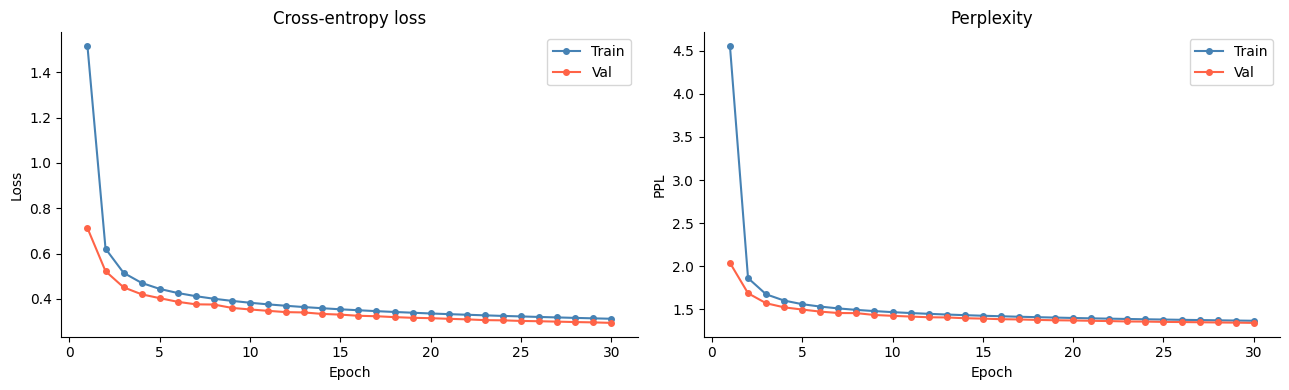

Final   — train loss 0.3120  val loss 0.2938
Best    — val loss   0.2938  (PPL 1.342)


In [26]:
n = len(train_losses)
xs = range(1, n + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(xs, train_losses, "o-", color="steelblue", ms=4, label="Train")
axes[0].plot(xs, val_losses,   "o-", color="tomato",    ms=4, label="Val")
axes[0].set_title("Cross-entropy loss"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss"); axes[0].legend()

axes[1].plot(xs, [math.exp(l) for l in train_losses], "o-", color="steelblue", ms=4, label="Train")
axes[1].plot(xs, [math.exp(l) for l in val_losses],   "o-", color="tomato",    ms=4, label="Val")
axes[1].set_title("Perplexity"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("PPL"); axes[1].legend()

for ax in axes:
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("loss_curves.png", dpi=120)
plt.show()
print(f"Final   — train loss {train_losses[-1]:.4f}  val loss {val_losses[-1]:.4f}")
print(f"Best    — val loss   {best_val:.4f}  (PPL {math.exp(best_val):.3f})")

## 9 — Quick Inference Verification  (best checkpoint)

In [27]:
# Reload best checkpoint
ckpt = torch.load(SAVE_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Loaded checkpoint — epoch {ckpt['epoch']}, val loss {ckpt['val_loss']:.4f}")


def correct_word(word: str) -> str:
    """Correct a single Georgian word using greedy decoding."""
    src     = torch.tensor([word_to_ids(word, MAX_INPUT_LEN)],
                           dtype=torch.long, device=DEVICE)
    src_len = torch.tensor([min(len(word), MAX_INPUT_LEN)], dtype=torch.long)
    preds   = model.greedy_decode(src, src_len)
    return ids_to_word(preds[0].tolist())


# 25 diverse test cases: mix of errors and already-correct words
test_cases = [
    # already-correct words ── model must pass them through unchanged
    ("გამარჯობა",    "გამარჯობა"),
    ("თბილისი",      "თბილისი"),
    ("საქართველო",   "საქართველო"),
    ("ქართული",      "ქართული"),
    ("კომპიუტერი",   "კომპიუტერი"),
    ("სკოლა",        "სკოლა"),
    ("მასწავლებელი", "მასწავლებელი"),
    ("ენა",          "ენა"),
    ("წიგნი",        "წიგნი"),
    ("სახელი",       "სახელი"),
    # omission errors ── missing character
    ("პროგამა",      "პროგრამა"),
    ("კომპიუტრი",    "კომპიუტერი"),
    ("გამრჯობა",     "გამარჯობა"),
    ("საქრთველო",    "საქართველო"),
    ("მსწავლებელი",  "მასწავლებელი"),
    # keyboard / transposition errors
    ("გამარჰობა",    "გამარჯობა"),
    ("ბთილისი",      "თბილისი"),
    ("ქართლი",       "ქართლი"),
    ("სახეიბ",       "სახელი"),
    ("წიბნი",        "წიგნი"),
    # phonetic confusion (ejective vs aspirate)
    ("ქარგი",        "კარგი"),
    ("თბილისი",      "თბილისი"),
    ("ქომპიუტერი",   "კომპიუტერი"),
    # insertion errors ── spurious extra char
    ("სკოლაა",       "სკოლა"),
    ("ენაი",         "ენა"),
]

correct_count = 0
print(f"{'INPUT':<24} {'PREDICTED':<24} {'EXPECTED':<24} PASS?")
print("─" * 85)
for inp, expected in test_cases:
    pred  = correct_word(inp)
    ok    = pred == expected
    correct_count += int(ok)
    mark  = "✓" if ok else "✗"
    print(f"{inp:<24} {pred:<24} {expected:<24} {mark}")

print()
print(f"Accuracy on test cases: {correct_count}/{len(test_cases)} "
      f"({correct_count/len(test_cases)*100:.0f}%)")

Loaded checkpoint — epoch 30, val loss 0.2938
INPUT                    PREDICTED                EXPECTED                 PASS?
─────────────────────────────────────────────────────────────────────────────────────
გამარჯობა                გამარჯობა                გამარჯობა                ✓
თბილისი                  თბილისი                  თბილისი                  ✓
საქართველო               საქართველო               საქართველო               ✓
ქართული                  ქართული                  ქართული                  ✓
კომპიუტერი               კომპიუტერი               კომპიუტერი               ✓
სკოლა                    სკოლა                    სკოლა                    ✓
მასწავლებელი             მასწავლებელი             მასწავლებელი             ✓
ენა                      ენა                      ენა                      ✓
წიგნი                    წიგნი                    წიგნი                    ✓
სახელი                   სახელი                   სახელი                   ✓
პროგამა          

## 10 — Save Model

The checkpoint written during training is self-contained — it bundles:
- `model_state` — all trained weights
- `char_vocab` — char↔index mappings and special token indices  
- `hparams` — architecture config needed to reconstruct the model in `inference.ipynb`

No separate vocab file is required at inference time.

In [28]:
print(f"Model path : {SAVE_PATH.resolve()}")
print(f"File size  : {SAVE_PATH.stat().st_size / 1e6:.1f} MB")
print()
print("Checkpoint keys:")
for k, v in ckpt.items():
    if k == "model_state":
        print(f"  model_state  — {len(v)} weight tensors")
    elif k == "char_vocab":
        print(f"  char_vocab   — vocab_size={v['vocab_size']}")
    elif k == "hparams":
        print(f"  hparams      — {v}")
    else:
        print(f"  {k:<12} — {v}")

Model path : /kaggle/working/georgian_spellcheck_model.pt
File size  : 10.7 MB

Checkpoint keys:
  epoch        — 30
  model_state  — 29 weight tensors
  val_loss     — 0.2938465403093325
  char_vocab   — vocab_size=43
  hparams      — {'embed_dim': 64, 'hidden_dim': 256, 'enc_layers': 2, 'dropout': 0.3, 'vocab_size': 43, 'max_input_len': 25, 'max_target_len': 25}
